# TEM Projector Simplified Zoom Model (No DAC)

This notebook uses the simplified projector model path in `temgym_core.projector_model`.

It ignores DAC curves and solves directly from:

- approximate geometry distances,
- strong objective and projector lenses (`~2 mm` focal length),
- weaker IL1/IL2/IL3 zoom-lens behavior,
- constraints on magnification, `B = 0`, and zero image rotation.


In [34]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Prefer the shared constants.py implementation when dependencies are available.
# Fallback keeps this notebook runnable in minimal environments.
try:
    from temgym_core.constants import compute_Rc_from_voltage as _compute_Rc_from_voltage_impl
    RC_SOURCE = 'temgym_core.constants.compute_Rc_from_voltage'
except Exception:
    RC_SOURCE = 'fallback_formula'

    def _compute_Rc_from_voltage_impl(U_accel: float) -> float:
        e = 1.602176634e-19
        m_e = 9.1093837015e-31
        c = 299792458.0
        mu_0 = 1.25663706212e-6
        gamma_rel = 1.0 + e * U_accel / (m_e * c * c)
        v_electron = c * np.sqrt(1.0 - 1.0 / (gamma_rel * gamma_rel))
        return float(e * mu_0 / (2.0 * m_e * v_electron))

def compute_Rc_from_voltage(U_accel: float) -> float:
    return float(_compute_Rc_from_voltage_impl(U_accel))

def _propagation_matrix_np(z: float) -> np.ndarray:
    return np.array(
        [[1.0, z, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]],
        dtype=float,
    )


def _lens_matrix_np(f: float) -> np.ndarray:
    return np.array(
        [[1.0, 0.0, 0.0], [-1.0 / f, 1.0, 0.0], [0.0, 0.0, 1.0]],
        dtype=float,
    )


def _build_abcd_np(dists: np.ndarray, focals: np.ndarray) -> np.ndarray:
    mtx = _propagation_matrix_np(float(dists[-1]))
    for i in reversed(range(len(focals))):
        mtx = mtx @ _lens_matrix_np(float(focals[i]))
        mtx = mtx @ _propagation_matrix_np(float(dists[i]))
    return mtx


%matplotlib widget




## Targets And Geometry

Edit distances below to your approximate column geometry.


{'Source': -0.6770833333333334, 'CL1': -0.4895833333333333, 'CL2': -0.4479166666666667, 'CLMini': -0.09583333333333333, 'Objective lens Pre': -0.010416666666666666, 'Sample': 0.0, 'Objective lens Post': 0.0020833333333333333, 'IL1': 0.22708333333333333, 'IL2': 0.2791666666666667, 'IL3': 0.3416666666666667, 'PL1': 0.39375, 'Screen': 0.71875}


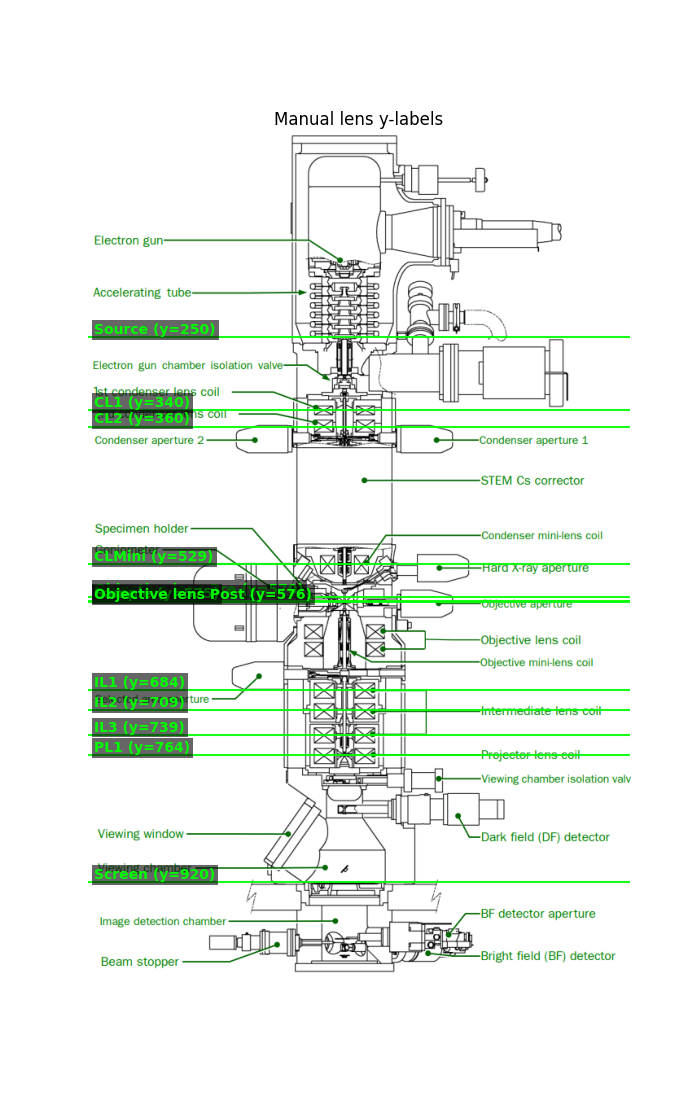

Distances between lenses (in meters): [0.1875     0.04166667 0.35208333 0.08541667 0.01041667 0.00208333
 0.225      0.05208333 0.0625     0.05208333 0.325     ]
CAD priors [mm]:
  d_source_to_opl_m: 679.167
  d_object_to_opl_m: 2.083
  d_opl_to_il1_m: 225.000
  d_il1_to_il2_m: 52.083
  d_il2_to_il3_m: 62.500
  d_il3_to_pl1_m: 52.083
  d_pl1_to_det_m: 325.000


In [35]:
# Manually fill y-pixel positions for each lens label.
# Leave as None until you set a value.
label_y = {
    "Source": 250,
    "CL1": 340,
    "CL2": 360,
    "CLMini": 529,
    "Objective lens Pre": 570,
    "Sample": 575,
    "Objective lens Post": 576,
    "IL1": 684,
    "IL2": 709,
    "IL3": 739,
    "PL1": 764,
    "Screen": 920,
}

length_scale_px = 624 - 528
length_scale_m = 0.2  # 20 cm - length of elliptical box on left hand side of image.
px_to_m = length_scale_m / length_scale_px

label_y_m = {k: (v - 575) * px_to_m if v is not None else None for k, v in label_y.items()}
print(label_y_m)

img = plt.imread('microscope.png')
# Plot image with horizontal label lines at each filled y value
fig, ax = plt.subplots(figsize=(7, 11))
ax.imshow(img, origin="upper")

for name, y in label_y.items():
    if y is None:
        continue
    y = int(y)
    ax.axhline(y, color="lime", lw=1.5, alpha=0.9)
    ax.text(
        8, y - 4, f"{name} (y={y})",
        color="lime", fontsize=10, fontweight="bold",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=2),
    )

ax.set_title("Manual lens y-labels")
ax.axis("off")
plt.show()

# Optional cleaned dict (only filled labels)
lens_z = {k: int(v) for k, v in label_y.items() if v is not None}
lens_z

y_vals_m = np.array([v for v in label_y_m.values() if v is not None], dtype=float)
distances = np.diff(y_vals_m - np.min(y_vals_m))
print("Distances between lenses (in meters):", distances)


def _abs_delta_m(a: str, b: str) -> float:
    va = label_y_m.get(a, None)
    vb = label_y_m.get(b, None)
    if va is None or vb is None:
        raise ValueError(f"Missing y-label(s) for '{a}' or '{b}'.")
    return float(abs(vb - va))


# CAD-derived geometric priors used by projector fit (source/objective/post-obj onwards).
CAD_PRIOR_DISTS_M = {
    'd_source_to_opl_m': _abs_delta_m('Source', 'Objective lens Post'),
    'd_object_to_opl_m': _abs_delta_m('Sample', 'Objective lens Post'),
    'd_opl_to_il1_m': _abs_delta_m('Objective lens Post', 'IL1'),
    'd_il1_to_il2_m': _abs_delta_m('IL1', 'IL2'),
    'd_il2_to_il3_m': _abs_delta_m('IL2', 'IL3'),
    'd_il3_to_pl1_m': _abs_delta_m('IL3', 'PL1'),
    'd_pl1_to_det_m': _abs_delta_m('PL1', 'Screen'),
}

print('CAD priors [mm]:')
for k, v in CAD_PRIOR_DISTS_M.items():
    print(f"  {k}: {1e3 * v:.3f}")



In [36]:
def load_raw_dac_hex_from_notebook(path: Path) -> dict:
    import ast
    nb = json.loads(path.read_text())
    for cell in nb['cells']:
        if cell.get('cell_type') != 'code':
            continue
        src = ''.join(cell.get('source', []))
        if 'RAW_DAC_HEX =' not in src:
            continue

        lines = src.splitlines()
        start = None
        for i, line in enumerate(lines):
            if line.strip().startswith('RAW_DAC_HEX ='):
                start = i
                break
        if start is None:
            continue

        buf = []
        brace_balance = 0
        for j in range(start, len(lines)):
            if j == start:
                part = lines[j][lines[j].find('{'):]
            else:
                part = lines[j]
            brace_balance += part.count('{') - part.count('}')
            buf.append(part)
            if brace_balance == 0:
                break

        return ast.literal_eval('\n'.join(buf))

    raise RuntimeError(f'RAW_DAC_HEX not found in {path}')


LENS = ['IL1', 'IL2', 'IL3', 'PL1']
raw_hex_path = Path('../lens_inversion/dac_lens_inversion.ipynb')
RAW_DAC_HEX = load_raw_dac_hex_from_notebook(raw_hex_path)

ALL_MAGS = np.array(sorted(int(k) for k in RAW_DAC_HEX.keys()), dtype=float)
ALL_CURRENTS = np.array(
    [[int(RAW_DAC_HEX[str(int(m))][ln], 16) for ln in LENS] for m in ALL_MAGS],
    dtype=float,
)

# Fit in Band C high range (where the trend is cleanest).
FIT_MAG_MIN = 80000.0
FIT_MAG_MAX = 600000.0
fit_mask = (ALL_MAGS >= FIT_MAG_MIN) & (ALL_MAGS <= FIT_MAG_MAX)
FIT_MAGS = ALL_MAGS[fit_mask]
FIT_CURRENTS_RAW = ALL_CURRENTS[fit_mask]

# Rotation model constants (electromagnetic lens model).
U_ACCEL_V = 200e3
RC_RAD_PER_AT = float(compute_Rc_from_voltage(U_ACCEL_V))
ROTATION_DAC_TO_AT_INIT = 1.0e-2
ROTATION_DAC_TO_AT_BOUNDS = (5.0e-3, 2.5e-2)
ROTATION_TERM_MIN_DEG = 1
ROTATION_TERM_MAX_DEG = 35.0
ROTATION_TERM_WEIGHT = 2.0
ROTATION_SIGNS = np.array([1.0, 1.0, 1.0, -1.0], dtype=float)  # IL1, IL2, IL3, PL1

# Initial DAC->AT scale (fit refines this later in cell 6).
ROTATION_DAC_TO_AT = float(np.clip(ROTATION_DAC_TO_AT_INIT, *ROTATION_DAC_TO_AT_BOUNDS))
RC_RAD_PER_DAC = RC_RAD_PER_AT * ROTATION_DAC_TO_AT

# Current preprocessing mode for the fit.
# - True : project onto exact zero-rotation manifold per setting.
# - False: keep raw DAC curves; rotation is handled by fitted Rc/rotation residual in cell 6.
USE_ROTATION_BALANCED_PROJECTION = False

rot_raw = FIT_CURRENTS_RAW @ ROTATION_SIGNS
denom = float(np.dot(ROTATION_SIGNS, ROTATION_SIGNS))
FIT_CURRENTS_PROJECTED = FIT_CURRENTS_RAW - (rot_raw[:, None] / max(denom, 1e-30)) * ROTATION_SIGNS[None, :]

if USE_ROTATION_BALANCED_PROJECTION:
    FIT_CURRENTS = FIT_CURRENTS_PROJECTED
    current_mode_label = 'rotation-balanced projection of raw DAC points'
else:
    FIT_CURRENTS = FIT_CURRENTS_RAW.copy()
    current_mode_label = 'raw DAC points (no projection)'

# Optional: force IL1 and IL2 to act together as a zoom pair by coupling
# their normalized log-current trajectories across magnification.
ENFORCE_IL12_ZOOM_COUPLING = True
IL12_ZOOM_COUPLING_STRENGTH = 0.80  # 0=no coupling, 1=full mode-lock
IL12_ZOOM_COUPLING_MODE = 'same_sign'  # 'opposed_sign' | 'same_sign'
REPROJECT_AFTER_IL12_ZOOM = True


def _apply_il12_zoom_coupling(currents: np.ndarray, strength: float, mode: str) -> tuple[np.ndarray, dict]:

    c = np.array(currents, dtype=float, copy=True)

    s = float(np.clip(strength, 0.0, 1.0))

    i1 = np.maximum(c[:, 0], 1e-12)

    i2 = np.maximum(c[:, 1], 1e-12)

    l1 = np.log(i1)

    l2 = np.log(i2)

    m1, m2 = float(np.mean(l1)), float(np.mean(l2))

    sd1 = max(float(np.std(l1)), 1e-12)

    sd2 = max(float(np.std(l2)), 1e-12)

    z1 = (l1 - m1) / sd1

    z2 = (l2 - m2) / sd2

    mode_norm = str(mode).strip().lower()

    if mode_norm == 'same_sign':

        z1_tgt = 0.5 * (z1 + z2)

        z2_tgt = z1_tgt

    elif mode_norm == 'opposed_sign':

        z1_tgt = 0.5 * (z1 - z2)

        z2_tgt = -z1_tgt

    else:

        raise ValueError(f'Unknown IL12_ZOOM_COUPLING_MODE: {mode}')



    z1_new = (1.0 - s) * z1 + s * z1_tgt

    z2_new = (1.0 - s) * z2 + s * z2_tgt

    c[:, 0] = np.exp(m1 + sd1 * z1_new)

    c[:, 1] = np.exp(m2 + sd2 * z2_new)

    diag = {

        'mode': mode_norm,

        'strength': s,

        'corr_before': float(np.corrcoef(z1, z2)[0, 1]) if len(z1) > 1 else 1.0,

        'corr_after': float(np.corrcoef(z1_new, z2_new)[0, 1]) if len(z1_new) > 1 else 1.0,

        'slope_il1_before': float(np.polyfit(np.arange(len(i1), dtype=float), i1, 1)[0]),

        'slope_il2_before': float(np.polyfit(np.arange(len(i2), dtype=float), i2, 1)[0]),

        'slope_il1_after': float(np.polyfit(np.arange(len(i1), dtype=float), c[:, 0], 1)[0]),

        'slope_il2_after': float(np.polyfit(np.arange(len(i2), dtype=float), c[:, 1], 1)[0]),

    }

    return c, diag



il12_zoom_diag = None
if ENFORCE_IL12_ZOOM_COUPLING:

    FIT_CURRENTS, il12_zoom_diag = _apply_il12_zoom_coupling(

        FIT_CURRENTS,

        IL12_ZOOM_COUPLING_STRENGTH,

        IL12_ZOOM_COUPLING_MODE,

    )

    if USE_ROTATION_BALANCED_PROJECTION and REPROJECT_AFTER_IL12_ZOOM:

        rot_tmp = FIT_CURRENTS @ ROTATION_SIGNS

        FIT_CURRENTS = FIT_CURRENTS - (rot_tmp[:, None] / max(denom, 1e-30)) * ROTATION_SIGNS[None, :]


rot_fit = FIT_CURRENTS @ ROTATION_SIGNS

print('Loaded DAC points:', len(ALL_MAGS))
print('Fit band:', FIT_MAG_MIN, 'to', FIT_MAG_MAX)
print('Fit points:', len(FIT_MAGS))
psi_raw_deg = np.degrees(RC_RAD_PER_DAC * rot_raw)
psi_fit_deg = np.degrees(RC_RAD_PER_DAC * rot_fit)
psi_terms_fit_deg = np.degrees(RC_RAD_PER_DAC * FIT_CURRENTS * ROTATION_SIGNS[None, :])

print('Current curves used in fit:', current_mode_label + '.')
print('  Rc source:', RC_SOURCE)
print('  Rc [rad/AT]:', float(RC_RAD_PER_AT))
print('  rotation DAC->AT init:', float(ROTATION_DAC_TO_AT))
print('  rotation DAC->AT bounds:', tuple(float(v) for v in ROTATION_DAC_TO_AT_BOUNDS))
print('  Rc [rad/DAC] init:', float(RC_RAD_PER_DAC))
print('  max |psi_total raw| [deg]:', float(np.max(np.abs(psi_raw_deg))))
print('  max |psi_total fit| [deg]:', float(np.max(np.abs(psi_fit_deg))))
print('  max |psi_term fit| [deg]:', float(np.max(np.abs(psi_terms_fit_deg))))
print('  projection enabled:', bool(USE_ROTATION_BALANCED_PROJECTION))
print('  max |ΔI| from projection [DAC units]:', float(np.max(np.abs(FIT_CURRENTS_PROJECTED - FIT_CURRENTS_RAW))))

print('  IL1/IL2 zoom coupling enabled:', bool(ENFORCE_IL12_ZOOM_COUPLING))

if il12_zoom_diag is not None:

    print('  IL1/IL2 zoom coupling mode:', str(IL12_ZOOM_COUPLING_MODE))

    print('  IL1/IL2 zoom coupling strength:', float(IL12_ZOOM_COUPLING_STRENGTH))

    print('  IL1/IL2 corr (before -> after):',

          float(il12_zoom_diag['corr_before']), '->', float(il12_zoom_diag['corr_after']))

    print('  IL1 slope before/after [DAC-step]:',

          float(il12_zoom_diag['slope_il1_before']), '->', float(il12_zoom_diag['slope_il1_after']))

    print('  IL2 slope before/after [DAC-step]:',

          float(il12_zoom_diag['slope_il2_before']), '->', float(il12_zoom_diag['slope_il2_after']))






Loaded DAC points: 31
Fit band: 80000.0 to 600000.0
Fit points: 10
Current curves used in fit: raw DAC points (no projection).
  Rc source: temgym_core.constants.compute_Rc_from_voltage
  Rc [rad/AT]: 0.0005301506025716662
  rotation DAC->AT init: 0.01
  rotation DAC->AT bounds: (0.005, 0.025)
  Rc [rad/DAC] init: 5.301506025716663e-06
  max |psi_total raw| [deg]: 12.3281566107869
  max |psi_total fit| [deg]: 13.953697988400945
  max |psi_term fit| [deg]: 19.440250901551313
  projection enabled: False
  max |ΔI| from projection [DAC units]: 10146.5
  IL1/IL2 zoom coupling enabled: True
  IL1/IL2 zoom coupling mode: same_sign
  IL1/IL2 zoom coupling strength: 0.8
  IL1/IL2 corr (before -> after): -0.9948082940375363 -> -0.8778192681471128
  IL1 slope before/after [DAC-step]: -113.0121212121201 -> -22.7546690384605
  IL2 slope before/after [DAC-step]: 2294.666666666666 -> 451.6173762938051


## Solve Simplified Projector Zoom Model

Defaults enforce strong OPL/PL (`2 mm`) and weaker IL lenses.

If many settings are marked unsuccessful, relax/tune:

- geometry distances,
- `il_current_bounds_at`,
- `weak_min_ratio`,
- `max_nfev`.


In [37]:
# Unknowns:
# d1..d5       : drifts [OPL->IL1, IL1->IL2, IL2->IL3, IL3->PL1, PL1->detector]
# f_opl        : objective strong-lens focal in this simplified stack
# Cf_lens      : shared lens geometry constant for IL1=IL2=IL3=PL1
# s_rot        : DAC->AT rotation scale (calibrated in fit, constrained)
# d0 fixed     : object->OPL drift (set from CAD prior)

D0_OBJECT_TO_OPL_M = float(CAD_PRIOR_DISTS_M['d_object_to_opl_m'])
B_MAX_TARGET_M = 1.0e-3   # requested image-plane bound: |B| < 1e-3
PSI_TARGET_RAD = 1.0e-9   # near-zero target for total image rotation
ROT_TOTAL_WEIGHT = 10.0

# Requested focal windows.
IL_F_MIN_M = 5.0e-3
IL_F_MAX_M = 25.0e-3
PL_F_MIN_M = 2.0e-3
PL_F_MAX_M = 6.0e-3
FOCAL_PRIOR_WEIGHT_IL = 1.0
FOCAL_PRIOR_WEIGHT_PL = 1.2

# CAD priors for modeled variable drifts d1..d5.
CAD_PRIOR_D_VAR_M = np.array([
    CAD_PRIOR_DISTS_M['d_opl_to_il1_m'],
    CAD_PRIOR_DISTS_M['d_il1_to_il2_m'],
    CAD_PRIOR_DISTS_M['d_il2_to_il3_m'],
    CAD_PRIOR_DISTS_M['d_il3_to_pl1_m'],
    CAD_PRIOR_DISTS_M['d_pl1_to_det_m'],
], dtype=float)
# Fit profile toggles for constraint strictness.
# strict: keeps CAD priors/bounds tight and strongly enforces B.
# low_mag_priority: relaxes CAD/B to recover the low-magnification setting.
FIT_PROFILE = 'low_mag_priority'  # 'strict' | 'low_mag_priority'
if FIT_PROFILE not in {'strict', 'low_mag_priority'}:
    raise ValueError(f'Unknown FIT_PROFILE: {FIT_PROFILE}')

if FIT_PROFILE == 'strict':
    CAD_PRIOR_REL_SIGMA = 0.15
    CAD_PRIOR_WEIGHT = 2.5
    CAD_BOUND_REL_LOW = 0.85
    CAD_BOUND_REL_HIGH = 1.15
    B_LINEAR_WEIGHT = 6.0
    B_CLIP_WEIGHT = 40.0
else:
    CAD_PRIOR_REL_SIGMA = 0.30
    CAD_PRIOR_WEIGHT = 0.2
    CAD_BOUND_REL_LOW = 0.40
    CAD_BOUND_REL_HIGH = 1.60
    B_LINEAR_WEIGHT = 0.5
    B_CLIP_WEIGHT = 1.0



# Relay zoom-chain constraints:
# 1) IL1 image plane must land on the front focal plane of IL2.
# 2) IL2+IL3 relay must image into the object plane of PL1.
# 3) IL2+IL3 behave as an afocal zoom pair (spacing ~= f2 + f3).
# 4) IL3 back focal plane aligns to PL1 object plane.
ENFORCE_RELAY_ZOOM_CHAIN = True
if FIT_PROFILE == 'strict':

    RELAY_IL1_TO_IL2_FFP_WEIGHT = 2.0

    RELAY_IL23_TO_PL1_OBJ_WEIGHT = 2.0

    RELAY_IL23_AFOCAL_WEIGHT = 1.5

    RELAY_IL3_TO_PL1_OBJ_WEIGHT = 1.2

else:

    RELAY_IL1_TO_IL2_FFP_WEIGHT = 1.2

    RELAY_IL23_TO_PL1_OBJ_WEIGHT = 1.2

    RELAY_IL23_AFOCAL_WEIGHT = 0.8

    RELAY_IL3_TO_PL1_OBJ_WEIGHT = 0.8

RELAY_NEGATIVE_DISTANCE_WEIGHT = 4.0

# Geometric relay planes (meters):
# - Selected-area/object plane for IL1 sits just before IL1.
# - Object plane of PL1 is fixed in front of PL1.
SAA_TO_IL1_M = 2.0e-3
PL1_OBJECT_TO_PL1_M = 2.0e-3


def decode_x(x: np.ndarray):
    d = np.exp(x[:5])
    f_opl = float(np.exp(x[5]))
    cf_lens = float(np.exp(x[6]))
    rot_dac_to_at = float(np.exp(x[7]))
    return d, f_opl, cf_lens, rot_dac_to_at


def forward_from_currents(mags: np.ndarray, currents: np.ndarray, x: np.ndarray):
    d_var, f_opl, cf_lens, rot_dac_to_at = decode_x(x)
    dists = np.array([D0_OBJECT_TO_OPL_M, *d_var], dtype=float)

    A_abs = []
    B_vals = []
    f_il_rows = []
    f_pl_rows = []

    relay_il1_to_il2_ffp_b_vals = []

    relay_il23_to_pl1_obj_b_vals = []

    relay_il23_afocal_err_vals = []

    relay_il3_to_pl1_obj_err_vals = []

    relay_il1_to_il2_ffp_dist_vals = []

    relay_il3_to_pl1_obj_dist_vals = []

    for i1, i2, i3, ipl in currents:
        f1 = 1.0 / max(cf_lens * i1 * i1, 1e-30)
        f2 = 1.0 / max(cf_lens * i2 * i2, 1e-30)
        f3 = 1.0 / max(cf_lens * i3 * i3, 1e-30)
        fp = 1.0 / max(cf_lens * ipl * ipl, 1e-30)

        mtx = _build_abcd_np(
            dists=dists,
            focals=np.array([f_opl, f1, f2, f3, fp], dtype=float),
        )
        A_abs.append(abs(float(mtx[0, 0])))
        B_vals.append(float(mtx[0, 1]))
        f_il_rows.append([f1, f2, f3])
        f_pl_rows.append(fp)

        # Relay-chain diagnostics for zoom-pair constraints.
        d1 = float(dists[1])

        relay_u_il1 = min(SAA_TO_IL1_M, max(1e-12, 0.95 * d1))

        d2 = float(dists[2])

        d3 = float(dists[3])

        d4 = float(dists[4])


        # IL1 image should form at IL2 front focal plane.
        v_il1_to_il2_ffp = d2 - f2

        v_il1_to_il2_ffp_safe = max(v_il1_to_il2_ffp, 1e-12)

        m_il1_to_il2_ffp = _build_abcd_np(

            dists=np.array([relay_u_il1, v_il1_to_il2_ffp_safe], dtype=float),

            focals=np.array([f1], dtype=float),

        )


        # IL2+IL3 should image onto the PL1 object plane.
        # PL1 object plane is taken as its front focal plane: f_PL1 before PL1.
        d_il3_to_pl1_obj = d4 - PL1_OBJECT_TO_PL1_M

        d_il3_to_pl1_obj_safe = max(d_il3_to_pl1_obj, 1e-12)

        m_il23_to_pl1_obj = _build_abcd_np(

            dists=np.array([max(f2, 1e-12), d3, d_il3_to_pl1_obj_safe], dtype=float),

            focals=np.array([f2, f3], dtype=float),

        )


        relay_il1_to_il2_ffp_b_vals.append(float(m_il1_to_il2_ffp[0, 1]))

        relay_il23_to_pl1_obj_b_vals.append(float(m_il23_to_pl1_obj[0, 1]))

        relay_il23_afocal_err_vals.append(float(d3 - (f2 + f3)))

        relay_il3_to_pl1_obj_err_vals.append(float(d_il3_to_pl1_obj - f3))

        relay_il1_to_il2_ffp_dist_vals.append(float(v_il1_to_il2_ffp))

        relay_il3_to_pl1_obj_dist_vals.append(float(d_il3_to_pl1_obj))

    psi_terms = RC_RAD_PER_AT * rot_dac_to_at * currents * ROTATION_SIGNS[None, :]
    psi_total = np.sum(psi_terms, axis=1)

    return {
        'dists_m': dists,
        'A_abs': np.array(A_abs, dtype=float),
        'B_m': np.array(B_vals, dtype=float),
        'f_il_m': np.array(f_il_rows, dtype=float),
        'f_pl_m': np.array(f_pl_rows, dtype=float),

        'relay_il1_to_il2_ffp_B_m': np.array(relay_il1_to_il2_ffp_b_vals, dtype=float),

        'relay_il23_to_pl1_obj_B_m': np.array(relay_il23_to_pl1_obj_b_vals, dtype=float),

        'relay_il23_afocal_err_m': np.array(relay_il23_afocal_err_vals, dtype=float),

        'relay_il3_to_pl1_obj_err_m': np.array(relay_il3_to_pl1_obj_err_vals, dtype=float),

        'relay_il1_to_il2_ffp_dist_m': np.array(relay_il1_to_il2_ffp_dist_vals, dtype=float),

        'relay_il3_to_pl1_obj_dist_m': np.array(relay_il3_to_pl1_obj_dist_vals, dtype=float),
        'psi_terms_rad': np.array(psi_terms, dtype=float),
        'psi_total_rad': np.array(psi_total, dtype=float),
    }


def residual_equal_il(x: np.ndarray) -> np.ndarray:
    out = forward_from_currents(FIT_MAGS, FIT_CURRENTS, x)
    A = out['A_abs']
    B = out['B_m']
    psi = out['psi_total_rad']
    psi_terms_deg_abs = np.abs(np.degrees(out['psi_terms_rad']).reshape(-1))
    d_var = out['dists_m'][1:]
    f_il = out['f_il_m'].reshape(-1)
    f_pl = out['f_pl_m']

    relay_il1_to_il2_ffp_B = out['relay_il1_to_il2_ffp_B_m']

    relay_il23_to_pl1_obj_B = out['relay_il23_to_pl1_obj_B_m']

    relay_il23_afocal_err = out['relay_il23_afocal_err_m']

    relay_il3_to_pl1_obj_err = out['relay_il3_to_pl1_obj_err_m']

    relay_il1_to_il2_ffp_dist = out['relay_il1_to_il2_ffp_dist_m']

    relay_il3_to_pl1_obj_dist = out['relay_il3_to_pl1_obj_dist_m']
    total_len = max(float(np.sum(out['dists_m'])), 1e-12)

    r = []

    # Match magnification shape across band C.
    r.extend(np.log(A[1:] / A[0]) - np.log(FIT_MAGS[1:] / FIT_MAGS[0]))

    # Keep image plane close to focus; enforce |B| < B_MAX_TARGET_M strongly.
    r.extend(B_LINEAR_WEIGHT * B / total_len)
    r.extend(B_CLIP_WEIGHT * np.clip(np.abs(B) - B_MAX_TARGET_M, 0.0, np.inf) / B_MAX_TARGET_M)

    # Keep total rotation near zero (projected or raw currents).
    r.extend(ROT_TOTAL_WEIGHT * (psi - 0.0) / max(PSI_TARGET_RAD, 1e-12))

    # Keep per-lens rotation contributions in a practical range.
    r.extend(ROTATION_TERM_WEIGHT * np.clip(ROTATION_TERM_MIN_DEG - psi_terms_deg_abs, 0.0, np.inf) / max(ROTATION_TERM_MIN_DEG, 1e-12))
    r.extend(ROTATION_TERM_WEIGHT * np.clip(psi_terms_deg_abs - ROTATION_TERM_MAX_DEG, 0.0, np.inf) / ROTATION_TERM_MAX_DEG)

    # CAD geometry priors on d1..d5 (log-domain, relative errors).
    r.extend(
        CAD_PRIOR_WEIGHT
        * (np.log(np.maximum(d_var, 1e-12)) - np.log(np.maximum(CAD_PRIOR_D_VAR_M, 1e-12)))
        / CAD_PRIOR_REL_SIGMA
    )

    # Soft physical priors: focal windows for IL and PL under shared Cf_lens.
    r.extend(FOCAL_PRIOR_WEIGHT_IL * np.clip(IL_F_MIN_M - f_il, 0.0, np.inf) / IL_F_MIN_M)
    r.extend(FOCAL_PRIOR_WEIGHT_IL * np.clip(f_il - IL_F_MAX_M, 0.0, np.inf) / IL_F_MAX_M)
    r.extend(FOCAL_PRIOR_WEIGHT_PL * np.clip(PL_F_MIN_M - f_pl, 0.0, np.inf) / PL_F_MIN_M)
    r.extend(FOCAL_PRIOR_WEIGHT_PL * np.clip(f_pl - PL_F_MAX_M, 0.0, np.inf) / PL_F_MAX_M)


    # Explicit relay chain constraints for IL1/IL2/IL3 -> PL1 object plane.
    if ENFORCE_RELAY_ZOOM_CHAIN:

        d1 = float(out['dists_m'][1])

        d2 = float(out['dists_m'][2])

        d3 = float(out['dists_m'][3])

        d4 = float(out['dists_m'][4])

        scale_12 = max(d1 + d2, 1e-12)

        scale_23 = max(d3 + d4, 1e-12)


        r.extend(RELAY_IL1_TO_IL2_FFP_WEIGHT * relay_il1_to_il2_ffp_B / scale_12)

        r.extend(RELAY_IL23_TO_PL1_OBJ_WEIGHT * relay_il23_to_pl1_obj_B / scale_23)

        r.extend(RELAY_IL23_AFOCAL_WEIGHT * relay_il23_afocal_err / max(d3, 1e-12))

        r.extend(RELAY_IL3_TO_PL1_OBJ_WEIGHT * relay_il3_to_pl1_obj_err / max(d4, 1e-12))


        # Keep virtual/object planes physically ordered.
        r.extend(RELAY_NEGATIVE_DISTANCE_WEIGHT * np.clip(-relay_il1_to_il2_ffp_dist, 0.0, np.inf) / max(d2, 1e-12))

        r.extend(RELAY_NEGATIVE_DISTANCE_WEIGHT * np.clip(-relay_il3_to_pl1_obj_dist, 0.0, np.inf) / max(d4, 1e-12))

        r.extend(np.array([RELAY_NEGATIVE_DISTANCE_WEIGHT * max(SAA_TO_IL1_M - d1, 0.0) / max(d1, 1e-12)], dtype=float))

        r.extend(np.array([RELAY_NEGATIVE_DISTANCE_WEIGHT * max(PL1_OBJECT_TO_PL1_M - d4, 0.0) / max(d4, 1e-12)], dtype=float))

    return np.array(r, dtype=float)


# Seed and bounds tightly anchored around CAD priors.
lb_d = np.maximum(1e-3, CAD_BOUND_REL_LOW * CAD_PRIOR_D_VAR_M)
ub_d = np.maximum(lb_d * 1.001, CAD_BOUND_REL_HIGH * CAD_PRIOR_D_VAR_M)
x0_d = np.clip(CAD_PRIOR_D_VAR_M, 1.01 * lb_d, 0.99 * ub_d)

# Hard Cf bounds implied by requested focal windows.
# For shared Cf over IL+PL, combine strict intervals and relax minimally if needed.
FOCAL_HARD_MARGIN_REL = 0.005

i_il_all = np.maximum(FIT_CURRENTS[:, :3].reshape(-1), 1e-12)
i_pl_all = np.maximum(FIT_CURRENTS[:, 3].reshape(-1), 1e-12)


def _cf_bounds_from_focal_window(i_all: np.ndarray, f_min_m: float, f_max_m: float):
    cf_lb_raw = float(np.max(1.0 / (f_max_m * i_all * i_all)))
    cf_ub_raw = float(np.min(1.0 / (f_min_m * i_all * i_all)))
    return cf_lb_raw, cf_ub_raw


cf_il_lb_raw, cf_il_ub_raw = _cf_bounds_from_focal_window(i_il_all, IL_F_MIN_M, IL_F_MAX_M)
cf_pl_lb_raw, cf_pl_ub_raw = _cf_bounds_from_focal_window(i_pl_all, PL_F_MIN_M, PL_F_MAX_M)

cf_lens_lb_raw = max(cf_il_lb_raw, cf_pl_lb_raw)
cf_lens_ub_raw = min(cf_il_ub_raw, cf_pl_ub_raw)

cf_lens_relax_k = 1.0
if cf_lens_lb_raw > cf_lens_ub_raw:
    cf_lens_relax_k = float(np.sqrt(cf_lens_lb_raw / cf_lens_ub_raw) * (1.0 + FOCAL_HARD_MARGIN_REL))

cf_lens_lb = max(1e-12, cf_lens_lb_raw / cf_lens_relax_k)
cf_lens_ub = min(1e-4, cf_lens_ub_raw * cf_lens_relax_k)

if cf_lens_lb >= cf_lens_ub:
    raise ValueError(f'No feasible shared Cf_lens interval even after relaxation: [{cf_lens_lb}, {cf_lens_ub}]')

cf_lens_x0 = float(np.clip(np.sqrt(cf_lens_lb * cf_lens_ub), 1.001 * cf_lens_lb, 0.999 * cf_lens_ub))
rot_scale_x0 = float(np.clip(ROTATION_DAC_TO_AT_INIT, *ROTATION_DAC_TO_AT_BOUNDS))

x0 = np.log(np.array([
    x0_d[0],
    x0_d[1],
    x0_d[2],
    x0_d[3],
    x0_d[4],
    0.00193,  # f_opl
    cf_lens_x0,  # Cf_lens shared over IL1/IL2/IL3/PL1
    rot_scale_x0,  # DAC->AT rotation scale
], dtype=float))

lb = np.log(np.array([
    lb_d[0], lb_d[1], lb_d[2], lb_d[3], lb_d[4],
    0.0008,
    cf_lens_lb,
    ROTATION_DAC_TO_AT_BOUNDS[0],
], dtype=float))
ub = np.log(np.array([
    ub_d[0], ub_d[1], ub_d[2], ub_d[3], ub_d[4],
    0.0050,
    cf_lens_ub,
    ROTATION_DAC_TO_AT_BOUNDS[1],
], dtype=float))

sol = least_squares(
    residual_equal_il,
    x0,
    bounds=(lb, ub),
    loss='soft_l1',
    max_nfev=5000,
)

fit_out = forward_from_currents(FIT_MAGS, FIT_CURRENTS, sol.x)
DISTS_M = fit_out['dists_m']
A_FIT_ABS = fit_out['A_abs']
B_FIT_M = fit_out['B_m']
PSI_TERMS_FIT_RAD = fit_out['psi_terms_rad']
PSI_FIT_RAD = fit_out['psi_total_rad']
F_IL_FIT_M = fit_out['f_il_m']
F_PL_FIT_M = fit_out['f_pl_m']

RELAY_IL1_TO_IL2_FFP_B_M = fit_out['relay_il1_to_il2_ffp_B_m']

RELAY_IL23_TO_PL1_OBJ_B_M = fit_out['relay_il23_to_pl1_obj_B_m']

RELAY_IL23_AFOCAL_ERR_M = fit_out['relay_il23_afocal_err_m']

RELAY_IL3_TO_PL1_OBJ_ERR_M = fit_out['relay_il3_to_pl1_obj_err_m']

RELAY_IL1_TO_IL2_FFP_DIST_M = fit_out['relay_il1_to_il2_ffp_dist_m']

RELAY_IL3_TO_PL1_OBJ_DIST_M = fit_out['relay_il3_to_pl1_obj_dist_m']

D_VAR_M, F_OPL_M, CF_LENS_SHARED, ROTATION_DAC_TO_AT = decode_x(sol.x)
CF_IL_SHARED = CF_LENS_SHARED
CF_PL1 = CF_LENS_SHARED
RC_RAD_PER_DAC = RC_RAD_PER_AT * ROTATION_DAC_TO_AT
MAG_SCALE = float(np.median(A_FIT_ABS / FIT_MAGS))
A_FIT_SCALED = A_FIT_ABS / MAG_SCALE

d_prior_mm = 1e3 * CAD_PRIOR_D_VAR_M
d_fit_mm = 1e3 * D_VAR_M
d_err_pct = 100.0 * (D_VAR_M - CAD_PRIOR_D_VAR_M) / np.maximum(CAD_PRIOR_D_VAR_M, 1e-12)

print('Solve success:', bool(sol.success), '| nfev:', int(sol.nfev), '| cost:', float(sol.cost))
print('Shared geometry constant enforced: IL1 == IL2 == IL3 == PL1')
print('fit profile:', FIT_PROFILE)
print('current preprocessing mode:', current_mode_label)
print('B residual weights [linear, clip]:', B_LINEAR_WEIGHT, B_CLIP_WEIGHT)
print('dists [mm]:', np.round(1e3 * DISTS_M, 3))
print('f_opl [mm]:', 1e3 * F_OPL_M)
print('Cf_lens_shared:', CF_LENS_SHARED)
print('rotation_dac_to_at fit:', ROTATION_DAC_TO_AT)
print('Rc [rad/AT]:', RC_RAD_PER_AT)
print('Rc [rad/DAC] fit:', RC_RAD_PER_DAC)
print('mag_scale:', MAG_SCALE)
print('CAD prior d1..d5 [mm]:', np.round(d_prior_mm, 3))
print('Fit d1..d5 [mm]:      ', np.round(d_fit_mm, 3))
print('Fit-prior diff [%]:   ', np.round(d_err_pct, 2))
print('CAD bounds [low, high] rel.:', CAD_BOUND_REL_LOW, CAD_BOUND_REL_HIGH)
print('Cf_il strict bounds from focal window:', cf_il_lb_raw, 'to', cf_il_ub_raw)
print('Cf_pl strict bounds from focal window:', cf_pl_lb_raw, 'to', cf_pl_ub_raw)
print('Cf_lens strict intersection:', cf_lens_lb_raw, 'to', cf_lens_ub_raw)
print('Cf_lens hard bounds used (relax k):', cf_lens_lb, 'to', cf_lens_ub, '| k =', cf_lens_relax_k)
print('Shared hard IL focal window used [mm]:', 1e3 * (IL_F_MIN_M / cf_lens_relax_k), 'to', 1e3 * (IL_F_MAX_M * cf_lens_relax_k))
print('Shared hard PL1 focal window used [mm]:', 1e3 * (PL_F_MIN_M / cf_lens_relax_k), 'to', 1e3 * (PL_F_MAX_M * cf_lens_relax_k))
print('Per-lens rotation target [deg]:', ROTATION_TERM_MIN_DEG, 'to', ROTATION_TERM_MAX_DEG)
print('max |psi_term| fit [deg]:', float(np.max(np.abs(np.degrees(PSI_TERMS_FIT_RAD)))))

print('relay zoom chain enabled:', bool(ENFORCE_RELAY_ZOOM_CHAIN))

print('relay weights [IL1->IL2 FFP, IL23->PL1 obj, IL23 afocal, IL3->PL1 obj]:',

      RELAY_IL1_TO_IL2_FFP_WEIGHT,

      RELAY_IL23_TO_PL1_OBJ_WEIGHT,

      RELAY_IL23_AFOCAL_WEIGHT,

      RELAY_IL3_TO_PL1_OBJ_WEIGHT)

print('relay plane assumptions [mm] (SAA->IL1, PL1_obj->PL1):', 1e3 * SAA_TO_IL1_M, 1e3 * PL1_OBJECT_TO_PL1_M)

print('max |relay IL1->IL2 FFP B| [mm]:', float(np.max(np.abs(RELAY_IL1_TO_IL2_FFP_B_M)) * 1e3))

print('max |relay IL23->PL1 object B| [mm]:', float(np.max(np.abs(RELAY_IL23_TO_PL1_OBJ_B_M)) * 1e3))

print('max |relay IL23 afocal err| [mm]:', float(np.max(np.abs(RELAY_IL23_AFOCAL_ERR_M)) * 1e3))

print('max |relay IL3->PL1 object err| [mm]:', float(np.max(np.abs(RELAY_IL3_TO_PL1_OBJ_ERR_M)) * 1e3))

print('min relay distances [mm] (IL2 FFP, IL3->PL1 obj):',

      float(np.min(RELAY_IL1_TO_IL2_FFP_DIST_M) * 1e3),

      float(np.min(RELAY_IL3_TO_PL1_OBJ_DIST_M) * 1e3))



Solve success: True | nfev: 23 | cost: 10199243201.794266
Shared geometry constant enforced: IL1 == IL2 == IL3 == PL1
fit profile: low_mag_priority
current preprocessing mode: raw DAC points (no projection)
B residual weights [linear, clip]: 0.5 1.0
dists [mm]: [  2.083  90.025  20.833  25.     20.833 130.   ]
f_opl [mm]: 2.0345397938507124
Cf_lens_shared: 2.058979017224936e-07
rotation_dac_to_at fit: 0.005000000000000006
Rc [rad/AT]: 0.0005301506025716662
Rc [rad/DAC] fit: 2.6507530128583344e-06
mag_scale: 0.4557011815397338
CAD prior d1..d5 [mm]: [225.     52.083  62.5    52.083 325.   ]
Fit d1..d5 [mm]:       [ 90.025  20.833  25.     20.833 130.   ]
Fit-prior diff [%]:    [-59.99 -60.   -60.   -60.   -60.  ]
CAD bounds [low, high] rel.: 0.4 1.6
Cf_il strict bounds from focal window: 3.923514652252668e-07 to 1.091341539868844e-07
Cf_pl strict bounds from focal window: 4.0690104166666665e-08 to 1.220703125e-07
Cf_lens strict intersection: 3.923514652252668e-07 to 1.091341539868844e-0

## Fit Table Diagnostics


In [38]:
err_fit_pct = 100.0 * (A_FIT_SCALED - FIT_MAGS) / FIT_MAGS
ratio_err_fit_pct = 100.0 * ((A_FIT_SCALED / A_FIT_SCALED[0]) / (FIT_MAGS / FIT_MAGS[0]) - 1.0)

print('Fit-band metrics (80k-600k):')
print('  median |mag error| [%]:', float(np.median(np.abs(err_fit_pct))))
print('  max |mag error| [%]:', float(np.max(np.abs(err_fit_pct))))
print('  median |ratio error| [%]:', float(np.median(np.abs(ratio_err_fit_pct))))
print('  max |ratio error| [%]:', float(np.max(np.abs(ratio_err_fit_pct))))
print('  max |B| [mm]:', float(np.max(np.abs(B_FIT_M)) * 1e3))
print('  B target [mm]:', 1e3 * B_MAX_TARGET_M)
print('  B target met:', bool(np.max(np.abs(B_FIT_M)) < B_MAX_TARGET_M))
print('  max |psi_total| [deg]:', float(np.max(np.abs(np.degrees(PSI_FIT_RAD)))))
print('  max |psi_term| [deg]:', float(np.max(np.abs(np.degrees(PSI_TERMS_FIT_RAD)))))
print('  IL focal range [mm]:', float(np.min(F_IL_FIT_M) * 1e3), 'to', float(np.max(F_IL_FIT_M) * 1e3))
print('  PL1 focal range [mm]:', float(np.min(F_PL_FIT_M) * 1e3), 'to', float(np.max(F_PL_FIT_M) * 1e3))

print('  max |relay IL1->IL2 FFP B| [mm]:', float(np.max(np.abs(RELAY_IL1_TO_IL2_FFP_B_M)) * 1e3))

print('  max |relay IL23->PL1 object B| [mm]:', float(np.max(np.abs(RELAY_IL23_TO_PL1_OBJ_B_M)) * 1e3))

print('  max |relay IL23 afocal err| [mm]:', float(np.max(np.abs(RELAY_IL23_AFOCAL_ERR_M)) * 1e3))

print('  max |relay IL3->PL1 object err| [mm]:', float(np.max(np.abs(RELAY_IL3_TO_PL1_OBJ_ERR_M)) * 1e3))

# Build a compact row table for plotting/reporting.
rows = []
for i, m in enumerate(FIT_MAGS):
    rows.append(
        {
            'magnification_target': float(m),
            'magnification_predicted': float(A_FIT_SCALED[i]),
            'magnification_error_pct': float(err_fit_pct[i]),
            'B': float(B_FIT_M[i]),
            'psi_total_rad': float(PSI_FIT_RAD[i]),
            'I0_IL1_at': float(FIT_CURRENTS[i, 0]),
            'I0_IL2_at': float(FIT_CURRENTS[i, 1]),
            'I0_IL3_at': float(FIT_CURRENTS[i, 2]),
            'I0_PL1_at': float(FIT_CURRENTS[i, 3]),
            'f_IL1_m': float(F_IL_FIT_M[i, 0]),
            'f_IL2_m': float(F_IL_FIT_M[i, 1]),
            'f_IL3_m': float(F_IL_FIT_M[i, 2]),
            'f_PL1_m': float(F_PL_FIT_M[i]),

            'relay_il1_to_il2_ffp_B_m': float(RELAY_IL1_TO_IL2_FFP_B_M[i]),

            'relay_il23_to_pl1_obj_B_m': float(RELAY_IL23_TO_PL1_OBJ_B_M[i]),

            'relay_il23_afocal_err_m': float(RELAY_IL23_AFOCAL_ERR_M[i]),

            'relay_il3_to_pl1_obj_err_m': float(RELAY_IL3_TO_PL1_OBJ_ERR_M[i]),
        }
    )

# Trend check in Band C.
idx = np.arange(len(rows), dtype=float)
i1 = np.array([r['I0_IL1_at'] for r in rows], dtype=float)
i2 = np.array([r['I0_IL2_at'] for r in rows], dtype=float)
i3 = np.array([r['I0_IL3_at'] for r in rows], dtype=float)
s1 = float(np.polyfit(idx, i1, 1)[0])

s2 = float(np.polyfit(idx, i2, 1)[0])

s3 = float(np.polyfit(idx, i3, 1)[0])

corr12 = float(np.corrcoef(i1, i2)[0, 1]) if len(i1) > 1 else 1.0

print('Band-C slopes [DAC-step]: IL1=', s1,

      'IL2=', s2,

      'IL3=', s3)

print('IL1/IL2 zoom-pair diagnostics:')

print('  corr(IL1, IL2):', corr12)

print('  slope ratio IL1/IL2:', float(s1 / s2) if abs(s2) > 1e-12 else np.nan)

same_sign_actual = bool(np.sign(s1) == np.sign(s2))

expected_same_sign = (str(IL12_ZOOM_COUPLING_MODE).strip().lower() == 'same_sign')

print('  slope sign expected/actual:', expected_same_sign, '/', same_sign_actual)





Fit-band metrics (80k-600k):
  median |mag error| [%]: 58.02355573148472
  max |mag error| [%]: 601.4927704699381
  median |ratio error| [%]: 85.74468558913176
  max |ratio error| [%]: 99.6478776133025
  max |B| [mm]: 2.9874329866856897
  B target [mm]: 1.0
  B target met: False
  max |psi_total| [deg]: 6.976848994200483
  max |psi_term| [deg]: 9.720125450775667
  IL focal range [mm]: 2.6502007323506858 to 47.639080090538364
  PL1 focal range [mm]: 1.1857363429038217 to 1.1857363429038217
  max |relay IL1->IL2 FFP B| [mm]: 6.521347630343016
  max |relay IL23->PL1 object B| [mm]: 9.679486179550764
  max |relay IL23 afocal err| [mm]: 25.598372208336468
  max |relay IL3->PL1 object err| [mm]: 28.805746024995123
Band-C slopes [DAC-step]: IL1= -22.7546690384605 IL2= 451.6173762938051 IL3= -2306.4848484848458
IL1/IL2 zoom-pair diagnostics:
  corr(IL1, IL2): -0.874957579491887
  slope ratio IL1/IL2: -0.05038483954093294
  slope sign expected/actual: True / False


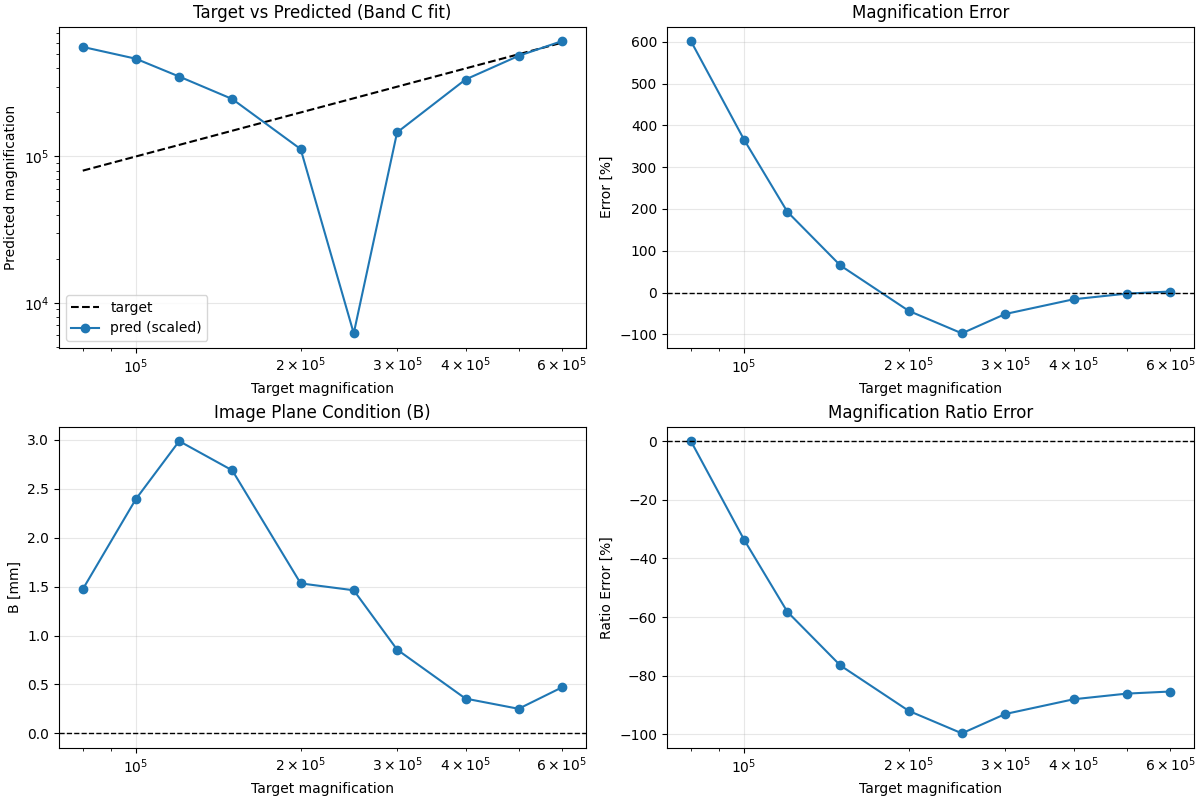

In [39]:
m_target = np.array([r['magnification_target'] for r in rows], dtype=float)
m_pred = np.array([r['magnification_predicted'] for r in rows], dtype=float)
err_pct = np.array([r['magnification_error_pct'] for r in rows], dtype=float)
B_vals = np.array([r['B'] for r in rows], dtype=float)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axs[0, 0].plot(m_target, m_target, 'k--', label='target')
axs[0, 0].plot(m_target, m_pred, 'o-', label='pred (scaled)')
axs[0, 0].set_xscale('log')
axs[0, 0].set_yscale('log')
axs[0, 0].set_xlabel('Target magnification')
axs[0, 0].set_ylabel('Predicted magnification')
axs[0, 0].set_title('Target vs Predicted (Band C fit)')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

axs[0, 1].plot(m_target, err_pct, 'o-')
axs[0, 1].axhline(0.0, color='k', lw=1, ls='--')
axs[0, 1].set_xscale('log')
axs[0, 1].set_xlabel('Target magnification')
axs[0, 1].set_ylabel('Error [%]')
axs[0, 1].set_title('Magnification Error')
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].plot(m_target, 1e3 * B_vals, 'o-')
axs[1, 0].axhline(0.0, color='k', lw=1, ls='--')
axs[1, 0].set_xscale('log')
axs[1, 0].set_xlabel('Target magnification')
axs[1, 0].set_ylabel('B [mm]')
axs[1, 0].set_title('Image Plane Condition (B)')
axs[1, 0].grid(True, alpha=0.3)

ratio_err_fit = 100.0 * ((m_pred / m_pred[0]) / (m_target / m_target[0]) - 1.0)
axs[1, 1].plot(m_target, ratio_err_fit, 'o-')
axs[1, 1].axhline(0.0, color='k', lw=1, ls='--')
axs[1, 1].set_xscale('log')
axs[1, 1].set_xlabel('Target magnification')
axs[1, 1].set_ylabel('Ratio Error [%]')
axs[1, 1].set_title('Magnification Ratio Error')
axs[1, 1].grid(True, alpha=0.3)

plt.show()


## Lens Current Curves


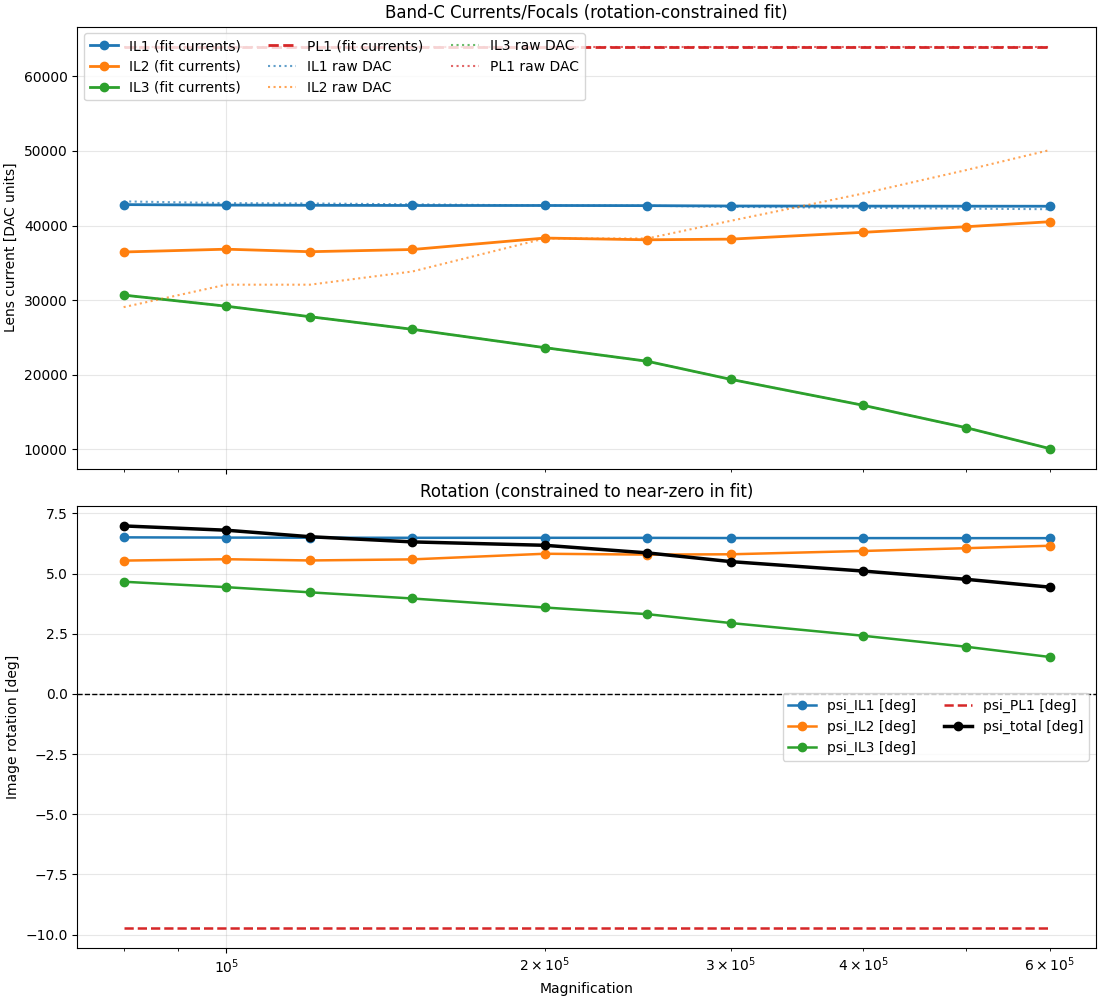

Rotation diagnostics:
  Rc [rad/AT]: 0.0005301506025716662
  rotation DAC->AT scale: 0.005000000000000006
  Rc [rad/DAC]: 2.6507530128583344e-06
  signs [IL1, IL2, IL3, PL1]: [1.0, 1.0, 1.0, -1.0]
  max |psi_total| [deg]: 6.976848994200483
  Rotation is now included in fit through current balancing + residual penalty.


In [40]:
# Compare currents/focals and show rotation decomposition for the fitted (rotation-balanced) set.
m_vals = FIT_MAGS.copy()

i_il1 = FIT_CURRENTS[:, 0]
i_il2 = FIT_CURRENTS[:, 1]
i_il3 = FIT_CURRENTS[:, 2]
i_pl1 = FIT_CURRENTS[:, 3]

i_il1_raw = FIT_CURRENTS_RAW[:, 0]
i_il2_raw = FIT_CURRENTS_RAW[:, 1]
i_il3_raw = FIT_CURRENTS_RAW[:, 2]
i_pl1_raw = FIT_CURRENTS_RAW[:, 3]

f_il1_mm = 1e3 * F_IL_FIT_M[:, 0]
f_il2_mm = 1e3 * F_IL_FIT_M[:, 1]
f_il3_mm = 1e3 * F_IL_FIT_M[:, 2]
f_pl1_mm = 1e3 * F_PL_FIT_M

psi_terms_rad = RC_RAD_PER_DAC * FIT_CURRENTS * ROTATION_SIGNS[None, :]
psi_total_rad = np.sum(psi_terms_rad, axis=1)
psi_terms_deg = np.degrees(psi_terms_rad)
psi_total_deg = np.degrees(psi_total_rad)

fig, axs = plt.subplots(2, 1, figsize=(11, 10), sharex=True, constrained_layout=True)

# Panel 1: currents + focal lengths
ax = axs[0]
ax.plot(m_vals, i_il1, 'o-', lw=2, label='IL1 (fit currents)')
ax.plot(m_vals, i_il2, 'o-', lw=2, label='IL2 (fit currents)')
ax.plot(m_vals, i_il3, 'o-', lw=2, label='IL3 (fit currents)')
ax.plot(m_vals, i_pl1, '--', lw=2, label='PL1 (fit currents)')

ax.plot(m_vals, i_il1_raw, color='C0', ls=':', lw=1.5, alpha=0.7, label='IL1 raw DAC')
ax.plot(m_vals, i_il2_raw, color='C1', ls=':', lw=1.5, alpha=0.7, label='IL2 raw DAC')
ax.plot(m_vals, i_il3_raw, color='C2', ls=':', lw=1.5, alpha=0.7, label='IL3 raw DAC')
ax.plot(m_vals, i_pl1_raw, color='C3', ls=':', lw=1.5, alpha=0.7, label='PL1 raw DAC')

ax.set_xscale('log')
ax.set_ylabel('Lens current [DAC units]')
ax.set_title('Band-C Currents/Focals (rotation-constrained fit)')
ax.grid(True, alpha=0.3)

h1, l1 = ax.get_legend_handles_labels()
ax.legend(h1, l1, ncol=3, loc='upper left')

# Panel 2: rotation contributions
axr = axs[1]
axr.plot(m_vals, psi_terms_deg[:, 0], 'o-', lw=1.8, label='psi_IL1 [deg]')
axr.plot(m_vals, psi_terms_deg[:, 1], 'o-', lw=1.8, label='psi_IL2 [deg]')
axr.plot(m_vals, psi_terms_deg[:, 2], 'o-', lw=1.8, label='psi_IL3 [deg]')
axr.plot(m_vals, psi_terms_deg[:, 3], '--', lw=1.8, label='psi_PL1 [deg]')
axr.plot(m_vals, psi_total_deg, 'k-o', lw=2.5, label='psi_total [deg]')
axr.axhline(0.0, color='k', ls='--', lw=1)
axr.set_xscale('log')
axr.set_xlabel('Magnification')
axr.set_ylabel('Image rotation [deg]')
axr.set_title('Rotation (constrained to near-zero in fit)')
axr.grid(True, alpha=0.3)
axr.legend(ncol=2, loc='best')

plt.show()

print('Rotation diagnostics:')
print('  Rc [rad/AT]:', float(RC_RAD_PER_AT))
print('  rotation DAC->AT scale:', float(ROTATION_DAC_TO_AT))
print('  Rc [rad/DAC]:', float(RC_RAD_PER_DAC))
print('  signs [IL1, IL2, IL3, PL1]:', ROTATION_SIGNS.tolist())
print('  max |psi_total| [deg]:', float(np.max(np.abs(psi_total_deg))))
print('  Rotation is now included in fit through current balancing + residual penalty.')





## Realize A Specific Magnification


In [41]:
requested_mag = 100000.0

# Interpolate DAC-locked currents on log-mag axis.
log_fit_m = np.log10(FIT_MAGS)
q = float(np.log10(np.clip(requested_mag, FIT_MAGS.min(), FIT_MAGS.max())))
I_req = np.array([
    np.interp(q, log_fit_m, FIT_CURRENTS[:, 0]),
    np.interp(q, log_fit_m, FIT_CURRENTS[:, 1]),
    np.interp(q, log_fit_m, FIT_CURRENTS[:, 2]),
    np.interp(q, log_fit_m, FIT_CURRENTS[:, 3]),
], dtype=float)

f1_req = 1.0 / max(CF_IL_SHARED * I_req[0] * I_req[0], 1e-30)
f2_req = 1.0 / max(CF_IL_SHARED * I_req[1] * I_req[1], 1e-30)
f3_req = 1.0 / max(CF_IL_SHARED * I_req[2] * I_req[2], 1e-30)
fp_req = 1.0 / max(CF_PL1 * I_req[3] * I_req[3], 1e-30)

mtx_req = _build_abcd_np(
    dists=DISTS_M,
    focals=np.array([F_OPL_M, f1_req, f2_req, f3_req, fp_req], dtype=float),
)
A_req_scaled = abs(float(mtx_req[0, 0])) / MAG_SCALE
B_req_mm = 1e3 * float(mtx_req[0, 1])

print('Requested mag:', requested_mag)
print('Interpolated DAC currents [IL1, IL2, IL3, PL1]:', I_req)
print('Predicted magnification (scaled):', A_req_scaled)
print('Predicted B [mm]:', B_req_mm)
print('Focals [mm] IL1/IL2/IL3/PL1:', 1e3 * np.array([f1_req, f2_req, f3_req, fp_req]))


Requested mag: 100000.0
Interpolated DAC currents [IL1, IL2, IL3, PL1]: [42744.59128711 36831.01214221 29189.         64000.        ]
Predicted magnification (scaled): 466077.2317910258
Predicted B [mm]: 2.3938439578614634
Focals [mm] IL1/IL2/IL3/PL1: [2.6581883  3.58031116 5.70045663 1.18573634]


## Build TemGym Components


In [42]:
print('Final fitted configuration (Band C, rotation-constrained, shared-lens geometry constant):')
print('  d_object_to_opl [mm]:', 1e3 * D0_OBJECT_TO_OPL_M, '(CAD prior)')
print('  d_opl_to_il1 [mm]:   ', 1e3 * DISTS_M[1], '| prior:', 1e3 * CAD_PRIOR_D_VAR_M[0])
print('  d_il1_to_il2 [mm]:   ', 1e3 * DISTS_M[2], '| prior:', 1e3 * CAD_PRIOR_D_VAR_M[1])
print('  d_il2_to_il3 [mm]:   ', 1e3 * DISTS_M[3], '| prior:', 1e3 * CAD_PRIOR_D_VAR_M[2])
print('  d_il3_to_pl1 [mm]:   ', 1e3 * DISTS_M[4], '| prior:', 1e3 * CAD_PRIOR_D_VAR_M[3])
print('  d_pl1_to_det [mm]:   ', 1e3 * DISTS_M[5], '| prior:', 1e3 * CAD_PRIOR_D_VAR_M[4])
print('  f_opl [mm]:          ', 1e3 * F_OPL_M)
print('  Cf_lens_shared (IL1/IL2/IL3/PL1):', CF_LENS_SHARED)
print('  Cf_pl1 (alias):      ', CF_PL1)
print('  B target [mm]:       ', 1e3 * B_MAX_TARGET_M)
print('  max |B| achieved [mm]:', float(np.max(np.abs(B_FIT_M)) * 1e3))
print('  max |psi_total| achieved [deg]:', float(np.max(np.abs(np.degrees(PSI_FIT_RAD)))))
print('  max |psi_term| achieved [deg]:', float(np.max(np.abs(np.degrees(PSI_TERMS_FIT_RAD)))))
print('  CAD prior weight/sigma:', CAD_PRIOR_WEIGHT, '/', CAD_PRIOR_REL_SIGMA)
print('  CAD bounds [low, high] rel.:', CAD_BOUND_REL_LOW, CAD_BOUND_REL_HIGH)

print('  IL1/IL2 zoom coupling enabled:', bool(ENFORCE_IL12_ZOOM_COUPLING),

      '| mode:', str(IL12_ZOOM_COUPLING_MODE),

      '| strength:', float(IL12_ZOOM_COUPLING_STRENGTH))

print('  relay zoom chain enabled:', bool(ENFORCE_RELAY_ZOOM_CHAIN))

print('  max |relay IL1->IL2 FFP B| [mm]:', float(np.max(np.abs(RELAY_IL1_TO_IL2_FFP_B_M)) * 1e3))

print('  max |relay IL23->PL1 object B| [mm]:', float(np.max(np.abs(RELAY_IL23_TO_PL1_OBJ_B_M)) * 1e3))

print('  max |relay IL23 afocal err| [mm]:', float(np.max(np.abs(RELAY_IL23_AFOCAL_ERR_M)) * 1e3))

print('  max |relay IL3->PL1 object err| [mm]:', float(np.max(np.abs(RELAY_IL3_TO_PL1_OBJ_ERR_M)) * 1e3))

print('  relay plane assumptions [mm] (SAA->IL1, PL1_obj->PL1):', 1e3 * SAA_TO_IL1_M, 1e3 * PL1_OBJECT_TO_PL1_M)

print('  IL focal target [mm]: ', 1e3 * IL_F_MIN_M, 'to', 1e3 * IL_F_MAX_M)
print('  PL1 focal target [mm]:', 1e3 * PL_F_MIN_M, 'to', 1e3 * PL_F_MAX_M)
print('  IL focal fit range [mm]:', float(np.min(F_IL_FIT_M) * 1e3), 'to', float(np.max(F_IL_FIT_M) * 1e3))
print('  PL1 focal fit range [mm]:', float(np.min(F_PL_FIT_M) * 1e3), 'to', float(np.max(F_PL_FIT_M) * 1e3))






Final fitted configuration (Band C, rotation-constrained, shared-lens geometry constant):
  d_object_to_opl [mm]: 2.0833333333333335 (CAD prior)
  d_opl_to_il1 [mm]:    90.02529219580029 | prior: 225.0
  d_il1_to_il2 [mm]:    20.833333759788076 | prior: 52.08333333333334
  d_il2_to_il3 [mm]:    25.000000712086077 | prior: 62.5
  d_il3_to_pl1 [mm]:    20.833334065543237 | prior: 52.083333333333314
  d_pl1_to_det [mm]:    130.00000257448156 | prior: 325.0
  f_opl [mm]:           2.0345397938507124
  Cf_lens_shared (IL1/IL2/IL3/PL1): 2.058979017224936e-07
  Cf_pl1 (alias):       2.058979017224936e-07
  B target [mm]:        1.0
  max |B| achieved [mm]: 2.9874329866856897
  max |psi_total| achieved [deg]: 6.976848994200483
  max |psi_term| achieved [deg]: 9.720125450775667
  CAD prior weight/sigma: 0.2 / 0.3
  CAD bounds [low, high] rel.: 0.4 1.6
  IL1/IL2 zoom coupling enabled: True | mode: same_sign | strength: 0.8
  relay zoom chain enabled: True
  max |relay IL1->IL2 FFP B| [mm]: 6.521

## Quick Ray Plot


In [43]:
# This notebook variant is focused on DAC-informed optical fitting with
# rotation-constrained currents and tighter image-plane (B) control,
# so we skip ray-trace component visualization here.
print('Ray visualization skipped in rotation-constrained DAC-fit mode.')



Ray visualization skipped in rotation-constrained DAC-fit mode.


## Export / Reload


In [44]:
out_path = Path('../ray_transfer/exported_microscope_models/projector_hex_locked_equal_il_config.json')
out_path.parent.mkdir(parents=True, exist_ok=True)

payload = {
    'fit_band_mag_min': float(FIT_MAG_MIN),
    'fit_band_mag_max': float(FIT_MAG_MAX),
    'lens_names': LENS,
    'dists_m': [float(v) for v in DISTS_M],
    'f_opl_m': float(F_OPL_M),
    'cf_lens_shared': float(CF_LENS_SHARED),
    'cf_il_shared': float(CF_IL_SHARED),
    'cf_pl1': float(CF_PL1),
    'shared_geometry_all_lenses': True,
    'mag_scale': float(MAG_SCALE),
    'currents_mode': ('rotation_balanced_projection' if USE_ROTATION_BALANCED_PROJECTION else 'raw_no_projection'),
    'use_rotation_balanced_projection': bool(USE_ROTATION_BALANCED_PROJECTION),

    'il12_zoom_coupling_enabled': bool(ENFORCE_IL12_ZOOM_COUPLING),

    'il12_zoom_coupling_strength': float(IL12_ZOOM_COUPLING_STRENGTH),

    'il12_zoom_coupling_mode': str(IL12_ZOOM_COUPLING_MODE),

    'relay_zoom_chain_enabled': bool(ENFORCE_RELAY_ZOOM_CHAIN),

    'relay_il1_to_il2_ffp_weight': float(RELAY_IL1_TO_IL2_FFP_WEIGHT),

    'relay_il23_to_pl1_obj_weight': float(RELAY_IL23_TO_PL1_OBJ_WEIGHT),

    'relay_il23_afocal_weight': float(RELAY_IL23_AFOCAL_WEIGHT),

    'relay_il3_to_pl1_obj_weight': float(RELAY_IL3_TO_PL1_OBJ_WEIGHT),

    'saa_to_il1_m': float(SAA_TO_IL1_M),

    'pl1_object_to_pl1_m': float(PL1_OBJECT_TO_PL1_M),
    'fit_profile': FIT_PROFILE,
    'rotation_signs': [float(v) for v in ROTATION_SIGNS],
    'rotation_dac_to_at': float(ROTATION_DAC_TO_AT),
    'rotation_dac_to_at_init': float(ROTATION_DAC_TO_AT_INIT),
    'rotation_dac_to_at_bounds': [float(v) for v in ROTATION_DAC_TO_AT_BOUNDS],
    'rotation_term_min_deg': float(ROTATION_TERM_MIN_DEG),
    'rotation_term_max_deg': float(ROTATION_TERM_MAX_DEG),
    'rc_rad_per_at': float(RC_RAD_PER_AT),
    'rc_rad_per_dac': float(RC_RAD_PER_DAC),
    'b_target_max_m': float(B_MAX_TARGET_M),
    'b_linear_weight': float(B_LINEAR_WEIGHT),
    'b_clip_weight': float(B_CLIP_WEIGHT),
    'max_abs_b_m': float(np.max(np.abs(B_FIT_M))),
    'max_abs_psi_total_rad': float(np.max(np.abs(PSI_FIT_RAD))),
    'max_abs_psi_term_rad': float(np.max(np.abs(PSI_TERMS_FIT_RAD))),

    'max_abs_relay_il1_to_il2_ffp_B_m': float(np.max(np.abs(RELAY_IL1_TO_IL2_FFP_B_M))),

    'max_abs_relay_il23_to_pl1_obj_B_m': float(np.max(np.abs(RELAY_IL23_TO_PL1_OBJ_B_M))),

    'max_abs_relay_il23_afocal_err_m': float(np.max(np.abs(RELAY_IL23_AFOCAL_ERR_M))),

    'max_abs_relay_il3_to_pl1_obj_err_m': float(np.max(np.abs(RELAY_IL3_TO_PL1_OBJ_ERR_M))),
    'cad_prior_dists_m': {k: float(v) for k, v in CAD_PRIOR_DISTS_M.items()},
    'cad_prior_d_var_m': [float(v) for v in CAD_PRIOR_D_VAR_M],
    'cad_prior_weight': float(CAD_PRIOR_WEIGHT),
    'cad_prior_rel_sigma': float(CAD_PRIOR_REL_SIGMA),
    'cad_bound_rel_low': float(CAD_BOUND_REL_LOW),
    'cad_bound_rel_high': float(CAD_BOUND_REL_HIGH),
    'il_focal_min_m': float(IL_F_MIN_M),
    'il_focal_max_m': float(IL_F_MAX_M),
    'pl1_focal_min_m': float(PL_F_MIN_M),
    'pl1_focal_max_m': float(PL_F_MAX_M),
    'focal_prior_weight_il': float(FOCAL_PRIOR_WEIGHT_IL),
    'focal_prior_weight_pl1': float(FOCAL_PRIOR_WEIGHT_PL),
}

out_path.write_text(json.dumps(payload, indent=2))
print('Saved config to:', out_path)








Saved config to: ../ray_transfer/exported_microscope_models/projector_hex_locked_equal_il_config.json
